In [29]:
# Multi-Label Molecular Taste Prediction Model
# ==============================================
# Using Mol2Vec (300d) + ChemBERTa (768d) embeddings
# Three output heads: Sweet, Bitter, Umami
# PyTorch implementation with class weighting, AUROC and F1 metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


## 1. Load and Prepare Data

In [30]:
# Load Mol2Vec and ChemBERTa embeddings
mol2vec_df = pd.read_csv('Embeddings/chemtastes_mol2vec.csv')
chemberta_df = pd.read_csv('Embeddings/chemtastes_chemberta.csv')

print("Mol2Vec shape:", mol2vec_df.shape)
print("ChemBERTa shape:", chemberta_df.shape)

# Display first few columns
print("\nMol2Vec columns (first 10):", mol2vec_df.columns[:10].tolist())
print("ChemBERTa columns (first 10):", chemberta_df.columns[:10].tolist())

Mol2Vec shape: (3849, 305)
ChemBERTa shape: (3849, 773)

Mol2Vec columns (first 10): ['Sweet', 'Bitter', 'Umami', 'Sour', 'Salty', 'mol2vec_0', 'mol2vec_1', 'mol2vec_2', 'mol2vec_3', 'mol2vec_4']
ChemBERTa columns (first 10): ['Sweet', 'Bitter', 'Umami', 'Sour', 'Salty', 'chemberta_0', 'chemberta_1', 'chemberta_2', 'chemberta_3', 'chemberta_4']


In [31]:
# Define label columns (we use only Sweet, Bitter, Umami for this model)
LABEL_COLS = ['Sweet', 'Bitter', 'Umami']

# Extract labels (should be the same in both dataframes)
labels = mol2vec_df[LABEL_COLS].values
print("Labels shape:", labels.shape)
print("\nLabel distribution:")
for i, col in enumerate(LABEL_COLS):
    positive = labels[:, i].sum()
    negative = len(labels) - positive
    print(f"  {col}: Positive={positive} ({positive/len(labels)*100:.1f}%), Negative={negative} ({negative/len(labels)*100:.1f}%)")

Labels shape: (3849, 3)

Label distribution:
  Sweet: Positive=1382 (35.9%), Negative=2467 (64.1%)
  Bitter: Positive=1758 (45.7%), Negative=2091 (54.3%)
  Umami: Positive=295 (7.7%), Negative=3554 (92.3%)


In [32]:
# Extract embedding features
mol2vec_cols = [col for col in mol2vec_df.columns if col.startswith('mol2vec_')]
chemberta_cols = [col for col in chemberta_df.columns if col.startswith('chemberta_')]

mol2vec_features = mol2vec_df[mol2vec_cols].values
chemberta_features = chemberta_df[chemberta_cols].values

print(f"Mol2Vec features: {mol2vec_features.shape}")
print(f"ChemBERTa features: {chemberta_features.shape}")

# Concatenate embeddings
X = np.concatenate([mol2vec_features, chemberta_features], axis=1)
y = labels

print(f"\nCombined features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Mol2Vec features: (3849, 300)
ChemBERTa features: (3849, 768)

Combined features shape: (3849, 1068)
Labels shape: (3849, 3)


In [33]:
# Train/Validation/Test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y[:, 1]  # Stratify by Bitter (most common)
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp[:, 1]
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Verify label distribution in each split
print("\nLabel distribution in splits:")
for name, data in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"\n{name}:")
    for i, col in enumerate(LABEL_COLS):
        pct = data[:, i].sum() / len(data) * 100
        print(f"  {col}: {pct:.1f}%")

Training set: 2694 samples
Validation set: 577 samples
Test set: 578 samples

Label distribution in splits:

Train:
  Sweet: 36.2%
  Bitter: 45.7%
  Umami: 7.5%

Val:
  Sweet: 35.7%
  Bitter: 45.8%
  Umami: 6.8%

Test:
  Sweet: 34.6%
  Bitter: 45.7%
  Umami: 9.5%
  Bitter: 45.8%
  Umami: 6.8%

Test:
  Sweet: 34.6%
  Bitter: 45.7%
  Umami: 9.5%


## 2. Compute Class Weights

In [ ]:
def compute_class_weights(y_train, label_names, strategy='effective_samples', beta=0.999):
    """
    Compute class weights for each label in multi-label classification.
    
    Strategies:
    - 'balanced': weight = n_neg / n_pos (standard)
    - 'sqrt_balanced': weight = sqrt(n_neg / n_pos) (less aggressive)
    - 'effective_samples': Class-Balanced Loss (Cui et al., 2019)
      Uses effective number of samples to handle extreme imbalance
    - 'focal_weight': Extra boost for very rare classes
    
    Args:
        y_train: Training labels
        label_names: List of label names
        strategy: Weighting strategy
        beta: Beta parameter for effective_samples strategy (0.9, 0.99, 0.999)
    """
    pos_weights = []
    
    print(f"Strategy: {strategy}")
    print("-" * 65)
    print(f"{'Label':<10} {'Pos':>8} {'Neg':>8} {'Pos%':>8} {'Weight':>12}")
    print("-" * 65)
    
    for i, label in enumerate(label_names):
        n_pos = int(y_train[:, i].sum())
        n_neg = len(y_train) - n_pos
        pos_pct = n_pos / len(y_train) * 100
        
        if strategy == 'balanced':
            # Standard: weight = n_neg / n_pos
            weight = n_neg / n_pos if n_pos > 0 else 1.0
            
        elif strategy == 'sqrt_balanced':
            # Less aggressive for very imbalanced data
            weight = np.sqrt(n_neg / n_pos) if n_pos > 0 else 1.0
            
        elif strategy == 'effective_samples':
            # Class-Balanced Loss using effective number of samples
            # Effective number: E_n = (1 - beta^n) / (1 - beta)
            effective_pos = (1 - beta**n_pos) / (1 - beta) if n_pos > 0 else 1
            effective_neg = (1 - beta**n_neg) / (1 - beta) if n_neg > 0 else 1
            weight = effective_neg / effective_pos
            
        elif strategy == 'focal_weight':
            # Higher weight for very rare classes
            base_weight = n_neg / n_pos if n_pos > 0 else 1.0
            rarity_factor = 1 + np.log1p(n_neg / max(n_pos, 1))
            weight = base_weight * rarity_factor
        
        else:
            weight = n_neg / n_pos if n_pos > 0 else 1.0
        
        pos_weights.append(weight)
        print(f"{label:<10} {n_pos:>8} {n_neg:>8} {pos_pct:>7.1f}% {weight:>12.2f}")
    
    print("-" * 65)
    
    return torch.tensor(pos_weights, dtype=torch.float32)


# Compare different weighting strategies
print("=" * 65)
print("CLASS WEIGHT COMPUTATION - Handling Imbalanced Data")
print("=" * 65)
print("\nUmami is severely underrepresented (~2.5%), need aggressive weighting!\n")

print("Comparing different weighting strategies:\n")

for strategy in ['balanced', 'effective_samples', 'focal_weight']:
    print(f"\n>>> {strategy.upper()}:")
    _ = compute_class_weights(y_train, LABEL_COLS, strategy=strategy)

# Use effective_samples for final training (best for extreme imbalance like Umami)
print("\n" + "=" * 65)
print("SELECTED: 'effective_samples' strategy (best for Umami imbalance)")
print("=" * 65 + "\n")

pos_weights = compute_class_weights(y_train, LABEL_COLS, strategy='effective_samples', beta=0.999)
pos_weights = pos_weights.to(device)
print(f"\nFinal pos_weights tensor: {pos_weights}")

Class weights (pos_weight for BCEWithLogitsLoss):
Sweet: pos=976, neg=1718, pos_weight=1.760
Bitter: pos=1230, neg=1464, pos_weight=1.190
Umami: pos=201, neg=2493, pos_weight=12.403

pos_weights tensor: tensor([ 1.7602,  1.1902, 12.4030])


## 3. PyTorch Dataset and DataLoader

In [35]:
class MolecularTasteDataset(Dataset):
    """Custom Dataset for molecular taste prediction."""
    
    def __init__(self, features, labels):
        """
        Args:
            features: numpy array of shape (n_samples, n_features)
            labels: numpy array of shape (n_samples, n_labels)
        """
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset = MolecularTasteDataset(X_train, y_train)
val_dataset = MolecularTasteDataset(X_val, y_val)
test_dataset = MolecularTasteDataset(X_test, y_test)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 43
Validation batches: 10
Test batches: 10


## 4. Multi-Head Neural Network Model

In [36]:
class MultiLabelTasteClassifier(nn.Module):
    """
    Multi-label classification model for molecular taste prediction.
    
    Architecture:
    - Shared dense layers process concatenated Mol2Vec + ChemBERTa embeddings
    - Three separate output heads (one per taste: Sweet, Bitter, Umami)
    - Each head outputs a single logit (sigmoid applied during inference)
    """
    
    def __init__(
        self, 
        input_dim: int = 1068,  # 300 (Mol2Vec) + 768 (ChemBERTa)
        hidden_dims: list = [512, 256, 128],
        num_labels: int = 3,
        dropout_rate: float = 0.3,
        use_batch_norm: bool = True
    ):
        super(MultiLabelTasteClassifier, self).__init__()
        
        self.num_labels = num_labels
        self.use_batch_norm = use_batch_norm
        
        # Build shared layers
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        self.shared_layers = nn.Sequential(*layers)
        
        # Build separate output heads for each taste
        # Each head: hidden_dim -> 32 -> 1
        self.output_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dims[-1], 32),
                nn.ReLU(),
                nn.Dropout(dropout_rate / 2),
                nn.Linear(32, 1)  # Output logit (no sigmoid - handled by loss)
            )
            for _ in range(num_labels)
        ])
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input tensor of shape (batch_size, input_dim)
            
        Returns:
            Tensor of shape (batch_size, num_labels) containing logits
        """
        # Shared representation
        shared_repr = self.shared_layers(x)
        
        # Pass through each output head
        outputs = []
        for head in self.output_heads:
            outputs.append(head(shared_repr))
        
        # Concatenate outputs: (batch_size, num_labels)
        return torch.cat(outputs, dim=1)
    
    def predict_proba(self, x):
        """Get probability predictions."""
        logits = self.forward(x)
        return torch.sigmoid(logits)
    
    def predict(self, x, threshold=0.5):
        """Get binary predictions."""
        probs = self.predict_proba(x)
        return (probs >= threshold).float()


# Model hyperparameters
INPUT_DIM = X_train.shape[1]  # 1068 (300 + 768)
HIDDEN_DIMS = [512, 256, 128]
NUM_LABELS = len(LABEL_COLS)
DROPOUT_RATE = 0.3

# Create model
model = MultiLabelTasteClassifier(
    input_dim=INPUT_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_labels=NUM_LABELS,
    dropout_rate=DROPOUT_RATE,
    use_batch_norm=True
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

MultiLabelTasteClassifier(
  (shared_layers): Sequential(
    (0): Linear(in_features=1068, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (output_heads): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=128, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.15, inplace=False)
      (3): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)

Total parameters: 725,827
Trainable parameters: 725,827


## 5. Loss Function and Optimizer

In [ ]:
class FocalLossWithLogits(nn.Module):
    """
    Focal Loss for multi-label classification with extreme class imbalance.
    
    Focal Loss: FL(p) = -alpha * (1-p)^gamma * log(p)
    
    - Reduces loss contribution from easy examples (high confidence correct predictions)
    - Focuses training on hard examples (low confidence or misclassified)
    - Especially useful for rare classes like Umami
    
    Reference: Lin et al., "Focal Loss for Dense Object Detection" (2017)
    """
    
    def __init__(self, gamma=2.0, pos_weight=None, reduction='sum'):
        """
        Args:
            gamma: Focusing parameter. gamma=0 is standard BCE, gamma>0 down-weights easy examples
            pos_weight: Weight for positive samples per class
            reduction: 'sum', 'mean', or 'none'
        """
        super(FocalLossWithLogits, self).__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: Raw model outputs (before sigmoid), shape (batch_size, num_labels)
            targets: Ground truth labels, shape (batch_size, num_labels)
        """
        # Get probabilities
        probs = torch.sigmoid(logits)
        
        # Binary cross entropy (without reduction)
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        
        # Focal weight: (1 - p_t)^gamma
        # p_t = p if y=1, else (1-p)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal weight
        focal_loss = focal_weight * bce
        
        # Apply class weights (pos_weight applies to positive samples)
        if self.pos_weight is not None:
            # Ensure pos_weight is on the same device
            weight = self.pos_weight * targets + (1 - targets)
            focal_loss = weight * focal_loss
        
        # Reduction
        if self.reduction == 'sum':
            return focal_loss.sum()
        elif self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss


# Choose loss function - Use Focal Loss for better handling of Umami imbalance
USE_FOCAL_LOSS = True

if USE_FOCAL_LOSS:
    # Focal Loss with gamma=2 (standard) and class weights
    criterion = FocalLossWithLogits(
        gamma=2.0,  # Higher gamma = more focus on hard examples
        pos_weight=pos_weights,
        reduction='sum'
    )
    print("✅ Using: FOCAL LOSS with gamma=2.0 and class weights")
    print("   - Down-weights easy/confident predictions")
    print("   - Focuses on hard examples (like rare Umami cases)")
    print("   - Better for extreme class imbalance")
else:
    # Standard BCE with class weights
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights, reduction='sum')
    print("Using: BCEWithLogitsLoss with class weights")

# Optimizer with weight decay for regularization
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler (reduce on plateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"\nClass weights (pos_weight): {pos_weights.cpu().tolist()}")
print(f"Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Loss function: BCEWithLogitsLoss (with pos_weight)
Optimizer: AdamW (lr=0.001, weight_decay=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


## 6. Evaluation Metrics

In [38]:
from sklearn.metrics import accuracy_score

def compute_metrics(y_true, y_pred_proba, y_pred, label_names):
    """
    Compute AUROC, F1 score, and Accuracy per label.
    
    Args:
        y_true: Ground truth labels (n_samples, n_labels)
        y_pred_proba: Predicted probabilities (n_samples, n_labels)
        y_pred: Binary predictions (n_samples, n_labels)
        label_names: List of label names
        
    Returns:
        Dictionary with metrics per label and overall
    """
    metrics = {}
    
    aurocs = []
    f1_scores = []
    accuracies = []
    
    for i, label in enumerate(label_names):
        # AUROC (requires probabilities)
        try:
            auroc = roc_auc_score(y_true[:, i], y_pred_proba[:, i])
        except ValueError:
            # If only one class present in y_true
            auroc = 0.5
        aurocs.append(auroc)
        
        # F1 Score (requires binary predictions)
        f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        f1_scores.append(f1)
        
        # Accuracy per label
        acc = accuracy_score(y_true[:, i], y_pred[:, i])
        accuracies.append(acc)
        
        metrics[f'{label}_AUROC'] = auroc
        metrics[f'{label}_F1'] = f1
        metrics[f'{label}_Accuracy'] = acc
    
    # Macro averages
    metrics['macro_AUROC'] = np.mean(aurocs)
    metrics['macro_F1'] = np.mean(f1_scores)
    metrics['macro_Accuracy'] = np.mean(accuracies)
    
    # Exact match accuracy (all labels correct for a sample)
    exact_match = np.all(y_true == y_pred, axis=1).mean()
    metrics['exact_match_accuracy'] = exact_match
    
    return metrics


def evaluate_model(model, dataloader, criterion, device, label_names):
    """
    Evaluate model on a dataset.
    
    Returns:
        Dictionary with loss and metrics
    """
    model.eval()
    
    all_labels = []
    all_proba = []
    all_preds = []
    total_loss = 0.0
    
    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            
            # Forward pass
            logits = model(features)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            
            # Get probabilities and predictions
            proba = torch.sigmoid(logits)
            preds = (proba >= 0.5).float()
            
            all_labels.append(labels.cpu().numpy())
            all_proba.append(proba.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    # Concatenate all batches
    y_true = np.vstack(all_labels)
    y_proba = np.vstack(all_proba)
    y_pred = np.vstack(all_preds)
    
    # Compute metrics
    metrics = compute_metrics(y_true, y_proba, y_pred, label_names)
    metrics['loss'] = total_loss / len(dataloader.dataset)
    
    return metrics, y_true, y_proba, y_pred


print("Evaluation functions defined successfully!")

Evaluation functions defined successfully!


## 7. Training Loop

In [ ]:
def train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device, 
    label_names,
    num_epochs=100,
    patience=15
):
    """
    Train the model with early stopping.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        device: Device (CPU/GPU)
        label_names: List of label names
        num_epochs: Maximum number of epochs
        patience: Early stopping patience
        
    Returns:
        history: Dictionary with training history
        best_model_state: State dict of best model
    """
    history = {
        'train_loss': [], 'val_loss': [],
        'train_macro_AUROC': [], 'val_macro_AUROC': [],
        'train_macro_F1': [], 'val_macro_F1': [],
    }
    
    # Add per-label metrics
    for label in label_names:
        history[f'train_{label}_AUROC'] = []
        history[f'val_{label}_AUROC'] = []
        history[f'train_{label}_F1'] = []
        history[f'val_{label}_F1'] = []
    
    best_val_auroc = 0.0
    best_model_state = None
    epochs_without_improvement = 0
    
    print("=" * 100)
    print("TRAINING WITH CLASS-BALANCED LOSS (Focal Loss + Effective Samples Weighting)")
    print("=" * 100)
    print(f"Monitoring per-class metrics to ensure balanced learning (especially for rare Umami class)")
    print()
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Evaluate on training set
        train_metrics, _, _, _ = evaluate_model(model, train_loader, criterion, device, label_names)
        
        # Evaluate on validation set
        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion, device, label_names)
        
        # Update learning rate scheduler
        scheduler.step(val_metrics['loss'])
        
        # Record history
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_macro_AUROC'].append(train_metrics['macro_AUROC'])
        history['val_macro_AUROC'].append(val_metrics['macro_AUROC'])
        history['train_macro_F1'].append(train_metrics['macro_F1'])
        history['val_macro_F1'].append(val_metrics['macro_F1'])
        
        for label in label_names:
            history[f'train_{label}_AUROC'].append(train_metrics[f'{label}_AUROC'])
            history[f'val_{label}_AUROC'].append(val_metrics[f'{label}_AUROC'])
            history[f'train_{label}_F1'].append(train_metrics[f'{label}_F1'])
            history[f'val_{label}_F1'].append(val_metrics[f'{label}_F1'])
        
        # Check for improvement
        if val_metrics['macro_AUROC'] > best_val_auroc:
            best_val_auroc = val_metrics['macro_AUROC']
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
            improvement_marker = ' *** BEST ***'
        else:
            epochs_without_improvement += 1
            improvement_marker = ''
        
        # Print progress every 5 epochs or at start
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"{'='*100}")
            print(f"Epoch {epoch+1:3d}/{num_epochs} | Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f}{improvement_marker}")
            print(f"-" * 100)
            
            # Per-class AUROC (critical for monitoring imbalanced classes)
            print(f"  Val AUROC per class:  Sweet={val_metrics['Sweet_AUROC']:.4f}  |  "
                  f"Bitter={val_metrics['Bitter_AUROC']:.4f}  |  "
                  f"Umami={val_metrics['Umami_AUROC']:.4f}  |  Macro={val_metrics['macro_AUROC']:.4f}")
            
            # Per-class F1 Score  
            print(f"  Val F1 per class:     Sweet={val_metrics['Sweet_F1']:.4f}  |  "
                  f"Bitter={val_metrics['Bitter_F1']:.4f}  |  "
                  f"Umami={val_metrics['Umami_F1']:.4f}  |  Macro={val_metrics['macro_F1']:.4f}")
            
            # Highlight if Umami is struggling
            if val_metrics['Umami_AUROC'] < 0.6:
                print(f"  ⚠️  WARNING: Umami AUROC ({val_metrics['Umami_AUROC']:.4f}) is low - model may be ignoring rare class!")
            elif val_metrics['Umami_AUROC'] < 0.75:
                print(f"  ⚠  Umami AUROC ({val_metrics['Umami_AUROC']:.4f}) is moderate - continue training...")
            else:
                print(f"  ✓ Umami AUROC ({val_metrics['Umami_AUROC']:.4f}) looks healthy!")
            
            print()
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\n{'='*100}")
            print(f"EARLY STOPPING at epoch {epoch+1} (no improvement for {patience} epochs)")
            print(f"{'='*100}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n{'='*100}")
        print(f"TRAINING COMPLETE - Loaded best model (Val Macro AUROC: {best_val_auroc:.4f})")
        print(f"{'='*100}")
    
    return history, best_model_state


print("Training function defined successfully!")
print("Note: Per-class metrics will be printed every 5 epochs to monitor class imbalance handling")

Training function defined successfully!



In [40]:
# Train the model
NUM_EPOCHS = 100
PATIENCE = 15

print("Starting training...")
print("=" * 80)

history, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    label_names=LABEL_COLS,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE
)

print("=" * 80)
print("Training complete!")

Starting training...
Epoch   1/100 | Train Loss: 1.7763 | Val Loss: 1.6841 | Val AUROC: 0.8604 | Val F1: 0.6309 *
Epoch   1/100 | Train Loss: 1.7763 | Val Loss: 1.6841 | Val AUROC: 0.8604 | Val F1: 0.6309 *
Epoch   5/100 | Train Loss: 1.2137 | Val Loss: 1.5033 | Val AUROC: 0.8957 | Val F1: 0.6887 
Epoch   5/100 | Train Loss: 1.2137 | Val Loss: 1.5033 | Val AUROC: 0.8957 | Val F1: 0.6887 
Epoch  10/100 | Train Loss: 0.7847 | Val Loss: 1.6529 | Val AUROC: 0.9074 | Val F1: 0.7374 
Epoch  10/100 | Train Loss: 0.7847 | Val Loss: 1.6529 | Val AUROC: 0.9074 | Val F1: 0.7374 
Epoch  15/100 | Train Loss: 0.5543 | Val Loss: 1.3751 | Val AUROC: 0.9209 | Val F1: 0.7757 *
Epoch  15/100 | Train Loss: 0.5543 | Val Loss: 1.3751 | Val AUROC: 0.9209 | Val F1: 0.7757 *
Epoch  20/100 | Train Loss: 0.4306 | Val Loss: 1.8022 | Val AUROC: 0.9185 | Val F1: 0.7675 
Epoch  20/100 | Train Loss: 0.4306 | Val Loss: 1.8022 | Val AUROC: 0.9185 | Val F1: 0.7675 
Epoch  25/100 | Train Loss: 0.3743 | Val Loss: 1.8356 |

## 8. Training Visualization

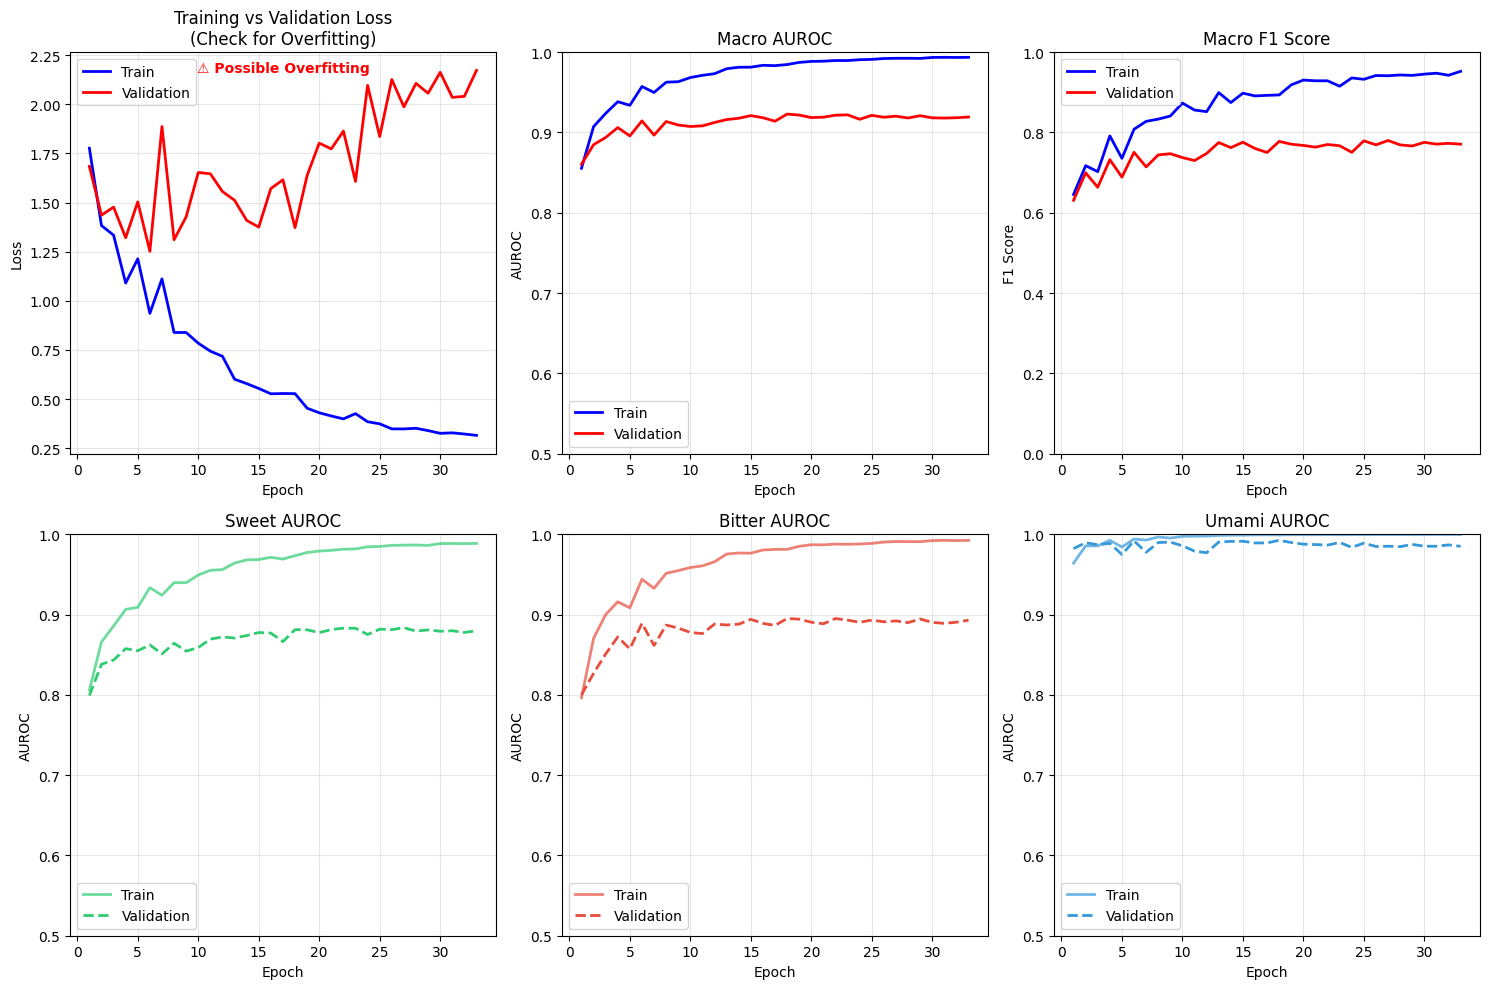


OVERFITTING ANALYSIS

Final Training Loss:   0.3156
Final Validation Loss: 2.1723
Gap (Val - Train):     1.8567

⚠️  WARNING: Significant overfitting detected!
   Consider: more dropout, less epochs, or data augmentation

Best Validation AUROC at Epoch: 18
Best Val AUROC: 0.9229


In [41]:
def plot_training_history(history, label_names):
    """Plot training history with loss curves to check for overfitting."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot 1: Loss (Key for detecting overfitting)
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    ax.plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training vs Validation Loss\n(Check for Overfitting)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add overfitting indicator
    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]
    gap = final_val_loss - final_train_loss
    if gap > final_train_loss * 0.2:  # If gap > 20% of train loss
        ax.annotate('⚠️ Possible Overfitting', xy=(0.5, 0.95), xycoords='axes fraction',
                   ha='center', fontsize=10, color='red', weight='bold')
    
    # Plot 2: Macro AUROC
    ax = axes[0, 1]
    ax.plot(epochs, history['train_macro_AUROC'], 'b-', label='Train', linewidth=2)
    ax.plot(epochs, history['val_macro_AUROC'], 'r-', label='Validation', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUROC')
    ax.set_title('Macro AUROC')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.5, 1.0])
    
    # Plot 3: Macro F1
    ax = axes[0, 2]
    ax.plot(epochs, history['train_macro_F1'], 'b-', label='Train', linewidth=2)
    ax.plot(epochs, history['val_macro_F1'], 'r-', label='Validation', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('Macro F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.0])
    
    # Plots 4-6: Per-label AUROC
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    for i, (label, color) in enumerate(zip(label_names, colors)):
        ax = axes[1, i]
        ax.plot(epochs, history[f'train_{label}_AUROC'], '-', color=color, alpha=0.7, label='Train', linewidth=2)
        ax.plot(epochs, history[f'val_{label}_AUROC'], '--', color=color, label='Validation', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('AUROC')
        ax.set_title(f'{label} AUROC')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.5, 1.0])
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print overfitting analysis
    print("\n" + "=" * 60)
    print("OVERFITTING ANALYSIS")
    print("=" * 60)
    print(f"\nFinal Training Loss:   {final_train_loss:.4f}")
    print(f"Final Validation Loss: {final_val_loss:.4f}")
    print(f"Gap (Val - Train):     {gap:.4f}")
    
    if gap > final_train_loss * 0.3:
        print("\n⚠️  WARNING: Significant overfitting detected!")
        print("   Consider: more dropout, less epochs, or data augmentation")
    elif gap > final_train_loss * 0.1:
        print("\n⚡ NOTICE: Mild overfitting observed.")
        print("   Model may benefit from regularization")
    else:
        print("\n✅ GOOD: No significant overfitting detected.")
    
    # Best epoch analysis
    best_epoch = np.argmax(history['val_macro_AUROC']) + 1
    print(f"\nBest Validation AUROC at Epoch: {best_epoch}")
    print(f"Best Val AUROC: {max(history['val_macro_AUROC']):.4f}")

# Plot training history
plot_training_history(history, LABEL_COLS)

## 9. Test Set Evaluation

In [42]:
# Evaluate on test set
test_metrics, y_true_test, y_proba_test, y_pred_test = evaluate_model(
    model, test_loader, criterion, device, LABEL_COLS
)

# Print detailed results
print("=" * 70)
print("TEST SET RESULTS")
print("=" * 70)

print(f"\nOverall Metrics:")
print(f"  Loss:                {test_metrics['loss']:.4f}")
print(f"  Macro AUROC:         {test_metrics['macro_AUROC']:.4f}")
print(f"  Macro F1:            {test_metrics['macro_F1']:.4f}")
print(f"  Macro Accuracy:      {test_metrics['macro_Accuracy']:.4f}")
print(f"  Exact Match Accuracy: {test_metrics['exact_match_accuracy']:.4f}")

print(f"\nPer-Label Metrics:")
print("-" * 60)
print(f"{'Label':<10} {'AUROC':>10} {'F1 Score':>12} {'Accuracy':>12}")
print("-" * 60)

for label in LABEL_COLS:
    auroc = test_metrics[f'{label}_AUROC']
    f1 = test_metrics[f'{label}_F1']
    acc = test_metrics[f'{label}_Accuracy']
    print(f"{label:<10} {auroc:>10.4f} {f1:>12.4f} {acc:>12.4f}")

print("-" * 60)

TEST SET RESULTS

Overall Metrics:
  Loss:                2.4616
  Macro AUROC:         0.9166
  Macro F1:            0.7677
  Macro Accuracy:      0.8564
  Exact Match Accuracy: 0.6713

Per-Label Metrics:
------------------------------------------------------------
Label           AUROC     F1 Score     Accuracy
------------------------------------------------------------
Sweet          0.8874       0.7290       0.7993
Bitter         0.8970       0.7955       0.8131
Umami          0.9655       0.7788       0.9567
------------------------------------------------------------


In [43]:
# Detailed classification report per label
print("\nDetailed Classification Reports:")
print("=" * 70)

for i, label in enumerate(LABEL_COLS):
    print(f"\n{label}:")
    print("-" * 40)
    print(classification_report(
        y_true_test[:, i], 
        y_pred_test[:, i],
        target_names=['Negative', 'Positive'],
        digits=4
    ))


Detailed Classification Reports:

Sweet:
----------------------------------------
              precision    recall  f1-score   support

    Negative     0.8743    0.8095    0.8407       378
    Positive     0.6842    0.7800    0.7290       200

    accuracy                         0.7993       578
   macro avg     0.7792    0.7948    0.7848       578
weighted avg     0.8085    0.7993    0.8020       578


Bitter:
----------------------------------------
              precision    recall  f1-score   support

    Negative     0.8280    0.8280    0.8280       314
    Positive     0.7955    0.7955    0.7955       264

    accuracy                         0.8131       578
   macro avg     0.8117    0.8117    0.8117       578
weighted avg     0.8131    0.8131    0.8131       578


Umami:
----------------------------------------
              precision    recall  f1-score   support

    Negative     0.9788    0.9732    0.9760       523
    Positive     0.7586    0.8000    0.7788        55



## 10. Confusion Matrices

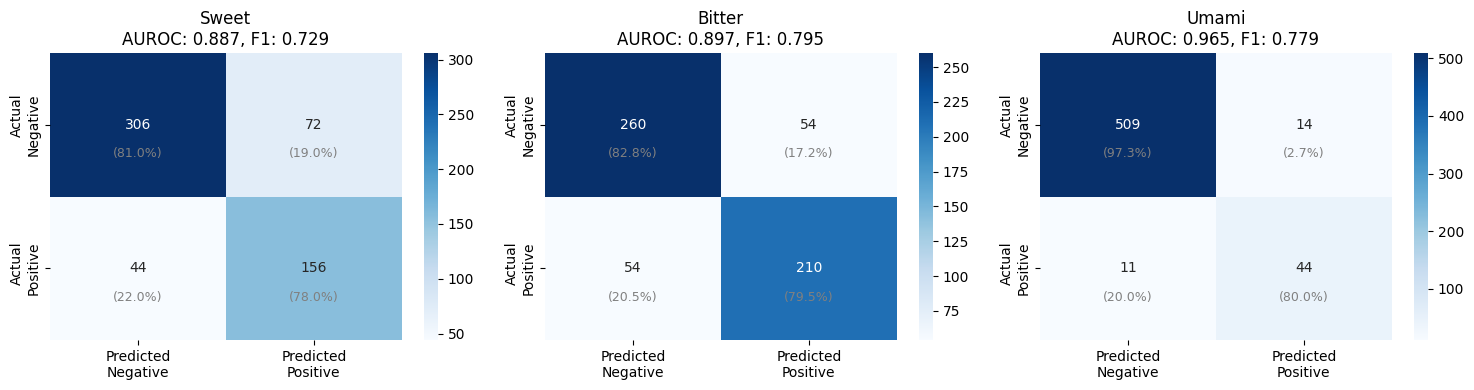

In [44]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (label, ax) in enumerate(zip(LABEL_COLS, axes)):
    cm = confusion_matrix(y_true_test[:, i], y_pred_test[:, i])
    
    # Normalize for percentage display
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Plot
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=['Predicted\nNegative', 'Predicted\nPositive'],
        yticklabels=['Actual\nNegative', 'Actual\nPositive'],
        ax=ax
    )
    
    # Add percentages
    for j in range(2):
        for k in range(2):
            ax.text(k + 0.5, j + 0.7, f'({cm_normalized[j, k]:.1f}%)', 
                   ha='center', va='center', fontsize=9, color='gray')
    
    ax.set_title(f'{label}\nAUROC: {test_metrics[f"{label}_AUROC"]:.3f}, F1: {test_metrics[f"{label}_F1"]:.3f}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC Curves

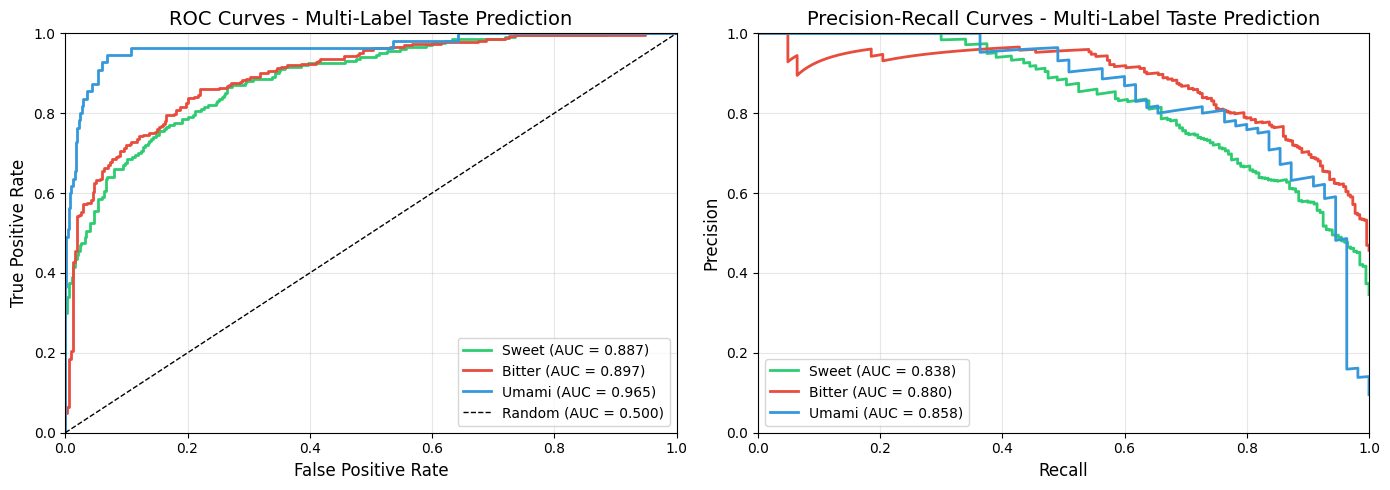

In [45]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c', '#3498db']

# ROC Curves
ax = axes[0]
for i, (label, color) in enumerate(zip(LABEL_COLS, colors)):
    fpr, tpr, _ = roc_curve(y_true_test[:, i], y_proba_test[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Multi-Label Taste Prediction', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision-Recall Curves
ax = axes[1]
for i, (label, color) in enumerate(zip(LABEL_COLS, colors)):
    precision, recall, _ = precision_recall_curve(y_true_test[:, i], y_proba_test[:, i])
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, lw=2, label=f'{label} (AUC = {pr_auc:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Multi-Label Taste Prediction', fontsize=14)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Model

In [46]:
# Save the model
MODEL_PATH = 'taste_classifier_model.pth'

# Save complete model state
checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_dim': INPUT_DIM,
        'hidden_dims': HIDDEN_DIMS,
        'num_labels': NUM_LABELS,
        'dropout_rate': DROPOUT_RATE,
        'label_names': LABEL_COLS
    },
    'training_config': {
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'batch_size': BATCH_SIZE,
        'pos_weights': pos_weights.cpu().tolist()
    },
    'test_metrics': test_metrics,
    'history': history
}

torch.save(checkpoint, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")
print(f"\nSaved contents:")
for key in checkpoint.keys():
    if key != 'model_state_dict' and key != 'history':
        print(f"  - {key}: {checkpoint[key]}")

Model saved to taste_classifier_model.pth

Saved contents:
  - model_config: {'input_dim': 1068, 'hidden_dims': [512, 256, 128], 'num_labels': 3, 'dropout_rate': 0.3, 'label_names': ['Sweet', 'Bitter', 'Umami']}
  - training_config: {'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'pos_weights': [1.7602459192276, 1.1902439594268799, 12.402984619140625]}
  - test_metrics: {'Sweet_AUROC': 0.88739417989418, 'Sweet_F1': 0.7289719626168224, 'Sweet_Accuracy': 0.7993079584775087, 'Bitter_AUROC': 0.8969793476162902, 'Bitter_F1': 0.7954545454545454, 'Bitter_Accuracy': 0.8131487889273357, 'Umami_AUROC': 0.9654788805840432, 'Umami_F1': 0.7787610619469026, 'Umami_Accuracy': 0.9567474048442907, 'macro_AUROC': np.float64(0.9166174693648378), 'macro_F1': np.float64(0.7677291900060901), 'macro_Accuracy': np.float64(0.856401384083045), 'exact_match_accuracy': np.float64(0.671280276816609), 'loss': 2.4616091943323406}


## 13. Load and Use Model (Inference Example)

In [47]:
def load_model(model_path, device):
    """Load saved model from checkpoint."""
    # weights_only=False needed for PyTorch 2.6+ when checkpoint contains non-tensor data
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # Create model with saved config
    config = checkpoint['model_config']
    model = MultiLabelTasteClassifier(
        input_dim=config['input_dim'],
        hidden_dims=config['hidden_dims'],
        num_labels=config['num_labels'],
        dropout_rate=config['dropout_rate']
    ).to(device)
    
    # Load state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model, config['label_names']


def predict_taste(model, mol2vec_embedding, chemberta_embedding, label_names, device, threshold=0.5):
    """
    Predict taste for a single molecule.
    
    Args:
        model: Trained model
        mol2vec_embedding: numpy array of shape (300,)
        chemberta_embedding: numpy array of shape (768,)
        label_names: List of label names
        device: Device
        threshold: Classification threshold
        
    Returns:
        Dictionary with predicted tastes and probabilities
    """
    # Concatenate embeddings
    features = np.concatenate([mol2vec_embedding, chemberta_embedding])
    features = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(features)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs >= threshold).astype(int)
    
    # Format results
    results = {
        'predictions': {},
        'probabilities': {}
    }
    
    for i, label in enumerate(label_names):
        results['predictions'][label] = bool(preds[i])
        results['probabilities'][label] = float(probs[i])
    
    return results


# Example: Load model and make predictions
print("Loading saved model...")
loaded_model, label_names = load_model(MODEL_PATH, device)

# Test on a few samples from test set
print("\nExample predictions on test samples:")
print("-" * 60)

for sample_idx in [0, 5, 10]:
    # Get embeddings for this sample
    mol2vec_emb = X_test[sample_idx, :300]
    chemberta_emb = X_test[sample_idx, 300:]
    
    # Predict
    results = predict_taste(loaded_model, mol2vec_emb, chemberta_emb, label_names, device)
    
    # True labels
    true_labels = {label: bool(y_test[sample_idx, i]) for i, label in enumerate(label_names)}
    
    print(f"\nSample {sample_idx}:")
    print(f"  True:      {true_labels}")
    print(f"  Predicted: {results['predictions']}")
    print(f"  Probs:     {{{', '.join([f'{k}: {v:.3f}' for k, v in results['probabilities'].items()])}}}")

Loading saved model...

Example predictions on test samples:
------------------------------------------------------------

Sample 0:
  True:      {'Sweet': True, 'Bitter': False, 'Umami': False}
  Predicted: {'Sweet': False, 'Bitter': False, 'Umami': False}
  Probs:     {Sweet: 0.403, Bitter: 0.319, Umami: 0.002}

Sample 5:
  True:      {'Sweet': True, 'Bitter': False, 'Umami': False}
  Predicted: {'Sweet': True, 'Bitter': True, 'Umami': False}
  Probs:     {Sweet: 0.892, Bitter: 0.702, Umami: 0.000}

Sample 10:
  True:      {'Sweet': True, 'Bitter': False, 'Umami': False}
  Predicted: {'Sweet': True, 'Bitter': False, 'Umami': False}
  Probs:     {Sweet: 0.997, Bitter: 0.002, Umami: 0.000}


## 14. Model Summary

In [48]:
# Final Model Summary
print("=" * 70)
print("MULTI-LABEL MOLECULAR TASTE PREDICTION MODEL - SUMMARY")
print("=" * 70)

print("\n📊 DATA:")
print(f"  • Total samples: {len(X)}")
print(f"  • Training: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")
print(f"  • Input dimensions: {INPUT_DIM} (Mol2Vec: 300 + ChemBERTa: 768)")
print(f"  • Labels: {', '.join(LABEL_COLS)}")

print("\n🏗️ ARCHITECTURE:")
print(f"  • Shared layers: {INPUT_DIM} → {' → '.join(map(str, HIDDEN_DIMS))}")
print(f"  • Output heads: 3 separate heads ({HIDDEN_DIMS[-1]} → 32 → 1 each)")
print(f"  • Activation: ReLU (hidden), Sigmoid (output)")
print(f"  • Regularization: BatchNorm, Dropout ({DROPOUT_RATE})")
print(f"  • Total parameters: {sum(p.numel() for p in model.parameters()):,}")

print("\n⚙️ TRAINING:")
print(f"  • Loss: BCEWithLogitsLoss (weighted)")
print(f"  • Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Early stopping patience: {PATIENCE}")

print("\n📈 TEST SET PERFORMANCE:")
print(f"  {'Label':<10} {'AUROC':>10} {'F1':>10} {'Accuracy':>12}")
print(f"  {'-'*42}")
for label in LABEL_COLS:
    print(f"  {label:<10} {test_metrics[f'{label}_AUROC']:>10.4f} {test_metrics[f'{label}_F1']:>10.4f} {test_metrics[f'{label}_Accuracy']:>12.4f}")
print(f"  {'-'*42}")
print(f"  {'Macro':<10} {test_metrics['macro_AUROC']:>10.4f} {test_metrics['macro_F1']:>10.4f} {test_metrics['macro_Accuracy']:>12.4f}")
print(f"\n  Exact Match Accuracy: {test_metrics['exact_match_accuracy']:.4f}")

print("\n💾 MODEL SAVED TO:", MODEL_PATH)
print("=" * 70)

MULTI-LABEL MOLECULAR TASTE PREDICTION MODEL - SUMMARY

📊 DATA:
  • Total samples: 3849
  • Training: 2694 | Validation: 577 | Test: 578
  • Input dimensions: 1068 (Mol2Vec: 300 + ChemBERTa: 768)
  • Labels: Sweet, Bitter, Umami

🏗️ ARCHITECTURE:
  • Shared layers: 1068 → 512 → 256 → 128
  • Output heads: 3 separate heads (128 → 32 → 1 each)
  • Activation: ReLU (hidden), Sigmoid (output)
  • Regularization: BatchNorm, Dropout (0.3)
  • Total parameters: 725,827

⚙️ TRAINING:
  • Loss: BCEWithLogitsLoss (weighted)
  • Optimizer: AdamW (lr=0.001, weight_decay=0.0001)
  • Batch size: 64
  • Early stopping patience: 15

📈 TEST SET PERFORMANCE:
  Label           AUROC         F1     Accuracy
  ------------------------------------------
  Sweet          0.8874     0.7290       0.7993
  Bitter         0.8970     0.7955       0.8131
  Umami          0.9655     0.7788       0.9567
  ------------------------------------------
  Macro          0.9166     0.7677       0.8564

  Exact Match Accura